# Análisis de volatilidad y estacionalidad en mercados de granos

Este proyecto analiza el comportamiento histórico de precios de commodities agrícolas
(soja, maíz y trigo) entre 2005 y 2025.

Este notebook descarga datos históricos de precios de commodities agrícolas
utilizando la API de Yahoo Finance.

Los datos luego se exportan a Excel para realizar análisis de:

- retornos
- volatilidad
- estacionalidad

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime


### Símbolos de Yahoo Finance para futuros continuos 
ZS=F → Soybeans (Soja) 

ZC=F → Corn (Maíz)

ZW=F → Wheat (Trigo, Soft Red Winter)

Los valores son los símbolos exactos que Yahoo Finance usa para esos futuros de commodities

In [2]:
commodities = {
    'Soybean': 'ZS=F',
    'Corn': 'ZC=F',
    'Wheat': 'ZW=F'
}

# Período: desde 2005 hasta finales de 2025
start_date = '2005-01-01'
end_date = datetime.today().strftime('2026-01-01')  # fecha actual automática

### Descarga de datos


In [ ]:
all_data = [] # Diccionario para guardar los datos

for name, symbol in commodities.items():
    print(f"Descargando datos de {name} ({symbol})...")
    try:
        # Descarga datos de OHLCV + Volume
        df = yf.download(symbol, start=start_date, end=end_date, progress=True)
        
        if df.empty:
            print(f"No se encontraron datos para {symbol}")
            continue
        
        # Agregado de columnas útiles 
        df = df.reset_index()  # fecha como columna
        df['commodity'] = name
        df = df[['Date', 'commodity', 'Open', 'High', 'Low', 'Close', 'Volume']]
        df.columns = ['date', 'commodity', 'open', 'high', 'low', 'close', 'volume'] 
        
        all_data.append(df)
        
    except Exception as e:
        print(f"Error al descargar {symbol}: {e}")

# Unir todo en un solo DataFrame
if all_data:
    final_df = pd.concat(all_data, ignore_index=True)
    
    # Ordenar por fecha y commodity
    final_df['date'] = pd.to_datetime(final_df['date'])
    final_df = final_df.sort_values(['date', 'commodity'])
    
    # Guardar como CSV 
    output_file = 'dataset_granos2.xlsx'
    final_df.to_excel(output_file, index=False)
    print(f"\n¡Datos guardados en '{output_file}'!")
    print(f"Filas totales: {len(final_df)}")
    print(final_df.head())
    print(final_df.tail())
else:
    print("No se descargó ningún dato.")

[*********************100%***********************]  1 of 1 completed

Descargando datos de Soybean (ZS=F)...
Descargando datos de Corn (ZC=F)...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Descargando datos de Wheat (ZW=F)...

¡Datos guardados en 'dataset_granos2.xlsx'!
Filas totales: 15850
            date commodity    open    high     low   close  volume
5284  2005-01-03      Corn  203.50  203.50  203.00  201.75    1743
0     2005-01-03   Soybean  546.00  546.00  541.50  537.25      47
10566 2005-01-03     Wheat  307.50  307.50  305.50  302.25     144
5285  2005-01-04      Corn  201.25  201.25  200.25  201.00    1357
1     2005-01-04   Soybean  536.50  536.50  535.50  529.75      54
            date commodity     open     high     low    close  volume
5282  2025-12-30   Soybean  1049.50  1053.50  1044.0  1046.25   38187
15848 2025-12-30     Wheat   512.75   515.50   510.0   510.75   36300
10565 2025-12-31      Corn   440.50   442.50   439.0   440.25   98189
5283  2025-12-31   Soybean  1045.00  1046.75  1030.0  1030.50    5656
15849 2025-12-31     Wheat   510.25   512.00   506.0   507.00   40225


### Limpieza del dataset

Ya que los retornos siempre se calculan comparando un precio con el precio inmediatamente anterior en el tiempo del mismo activo, usamos sort_values para ordenar primero por commodity y dentro de cada commodity se ordena por fecha

In [ ]:
df = pd.read_csv('dataset_granos.csv')
df = df.sort_values(["commodity","date"])
df.head


<bound method NDFrame.head of              date commodity    open    high     low   close  volume
0      2005-01-03      Corn  203.50  203.50  203.00  201.75    1743
3      2005-01-04      Corn  201.25  201.25  200.25  201.00    1357
6      2005-01-05      Corn  201.00  201.25  200.50  201.50    1159
9      2005-01-06      Corn  201.50  203.25  201.50  208.75    7093
12     2005-01-07      Corn  207.50  208.75  207.50  206.75    1307
...           ...       ...     ...     ...     ...     ...     ...
15837  2025-12-24     Wheat  518.50  525.00  518.00  521.75   32999
15840  2025-12-26     Wheat  522.50  524.50  517.00  519.00   38020
15843  2025-12-29     Wheat  518.00  521.00  512.00  513.00   43201
15846  2025-12-30     Wheat  512.75  515.50  510.00  510.75   36300
15849  2025-12-31     Wheat  510.25  512.00  506.00  507.00   40225

[15850 rows x 7 columns]>

In [42]:
df["date"] = pd.to_datetime(df["date"])

### Exploración inicial (EDA)

In [33]:
df.describe()

,date,open,high,low,close,volume
count,5284,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000
mean,2015-06-30 07:58:00,584.716030,592.838806,576.604892,584.175956,40600.676949
min,2005-01-03 00:00:00,288.250000,288.750000,288.000000,287.750000,0.000000
25%,2010-03-30 18:00:00,480.937500,487.750000,474.687500,481.000000,6616.750000
50%,2015-06-29 12:00:00,546.000000,553.500000,539.000000,546.000000,41481.500000
75%,2020-09-29 06:00:00,675.812500,687.312500,666.250000,675.312500,62077.250000
max,2025-12-31 00:00:00,1340.000000,1425.250000,1311.250000,1425.250000,166632.000000
std,NaN,160.549238,164.730018,156.214819,160.256486,31797.187617


In [28]:
df.shape

(5284, 7)

Contamos con 5284 filas y 7 columnas

In [43]:
df.dtypes

date         datetime64[s]
commodity              str
open               float64
high               float64
low                float64
close              float64
volume               int64
dtype: object

In [44]:
df.columns

Index(['date', 'commodity', 'open', 'high', 'low', 'close', 'volume'], dtype='str')

### Calculo de Drawndrown para entender la resiliencia ante shocks

leemos dataset de precios normalizados extraidos de excel y eliminamos columnas innecesarias

In [12]:
df2 = pd.read_excel('precios_normalizados.xlsx')
df2.head()

df2 = df2.drop(columns=['open', 'high', 'low', 'close', 'volume', 'Cambio de Precio', 'Volatilidad Hist Anual (40 Ruedas)'])
df2.head()

,date,commodity,Precio Normalizado
0,2005-01-03,Corn,100.000000
1,2005-01-04,Corn,99.628253
2,2005-01-05,Corn,99.876084
3,2005-01-06,Corn,103.469641
4,2005-01-07,Corn,102.478315


In [29]:
df2.columns

Index(['date', 'commodity', 'Precio Normalizado'], dtype='str')

convertimos dataset a formato wide

In [30]:
wide = df2.pivot_table(index='date',
                      columns='commodity',
                      values='Precio Normalizado',
                      aggfunc='mean')   # o sum, max…
wide.head()
wide = wide.reset_index() # para que 'date' vuelva a ser una columna normal y no el índice

En el siguiente bloque, se convierte la columna de fecha diaria a mes en promedio

In [37]:
# Setear fecha como índice
wide = wide.set_index('date')

# Resamplear a mensual con promedio
wide_monthly = wide.resample('ME').mean()

# Resetear índice
wide_monthly = wide_monthly.reset_index()

wide_monthly.head()

commodity,date,Corn,Soybean,Wheat,drawdown_corn,drawdown_soybean,drawdown_wheat
0,2005-01-31,99.194548,99.118195,99.032258,-0.036296,-0.040666,-0.029817
1,2005-02-28,99.302159,100.093067,99.425362,-0.042420,-0.053243,-0.039367
2,2005-03-31,105.981751,118.122594,112.722761,-0.038176,-0.033814,-0.040679
3,2005-04-30,103.038886,115.885572,103.619678,-0.090237,-0.085763,-0.148939
4,2005-05-31,103.151000,118.265417,104.324708,-0.089247,-0.066988,-0.143148


### Creamos la funcion para calcular el drawdown

In [20]:
def calcular_drawdown(serie):
    maximo_acumulado = serie.cummax()
    drawdown = (serie - maximo_acumulado) / maximo_acumulado
    return drawdown


In [31]:
wide['drawdown_corn'] = calcular_drawdown(wide['Corn'])
wide['drawdown_soybean'] = calcular_drawdown(wide['Soybean'])
wide['drawdown_wheat'] = calcular_drawdown(wide['Wheat'])

Descargamos dataset con las columnas nuevas de drawdown

In [38]:
wide.to_excel("dataset_drawdown_granos.xlsx", index=False)

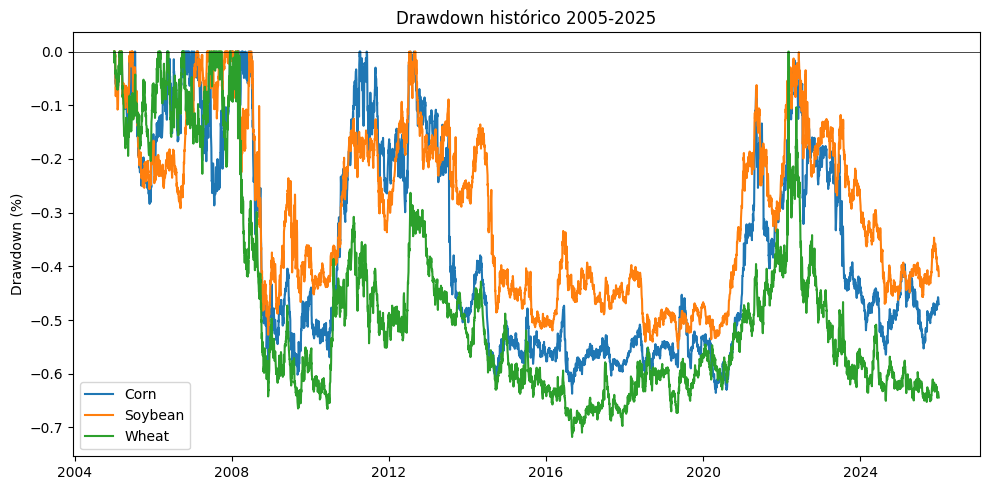

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(wide['date'], wide['drawdown_corn'], label='Corn')
plt.plot(wide['date'], wide['drawdown_soybean'], label='Soybean')
plt.plot(wide['date'], wide['drawdown_wheat'], label='Wheat')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Drawdown histórico 2005-2025')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.tight_layout()
plt.show()

### Graficos


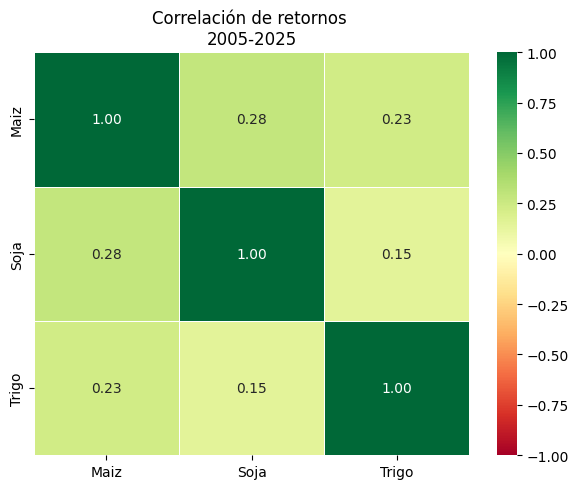

In [5]:
# Tu matriz de correlación
corr_matrix = np.array([
    [1.000, 0.285, 0.230],
    [0.285, 1.000, 0.146],
    [0.230, 0.146, 1.000]
])

labels = ['Maiz', 'Soja', 'Trigo']

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    xticklabels=labels,
    yticklabels=labels,
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Correlación de retornos \n2005-2025')
plt.tight_layout()
plt.savefig('correlacion_commodities.png', dpi=150)
plt.show()

### Guardar dataset

In [47]:
df.to_excel("dataset_granos.xlsx", index=False)